# BrandPulse AI — Notebook 01
## Preprocessing & Classical NLP (TF-IDF + Logistic Regression / Naive Bayes)

**Case study:** automated Voice-of-Customer sentiment on airline tweets.
**Dataset:** Twitter US Airline Sentiment (14,640 human-labelled tweets, 3 classes).

This notebook covers:
- **Phase 1 — Data Wrangling:** load, EDA, regex cleaning, lemmatization, WordClouds
- **Phase 2A — Classical baseline:** TF-IDF vectorisation + Logistic Regression & Naive Bayes

> All text cleaning is imported from `src/preprocess.py` — the *same* module the
> Streamlit app uses at inference time, so there is zero train/serve drift.


### Setup & imports

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))  # so we can import src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

from src.preprocess import clean_series, clean_tweet, LABELS, LABEL2ID, ID2LABEL

sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', 100)
print('Labels:', LABELS)

Labels: ['negative', 'neutral', 'positive']


---
# Phase 1 — Data Wrangling
*Goal: clean the noise.*

### 1.1 Load the data

In [2]:
df = pd.read_csv('../data/raw/Tweets.csv')
print('Shape:', df.shape)
df[['airline_sentiment', 'airline', 'text', 'tweet_created']].head()

Shape: (14640, 15)


,airline_sentiment,airline,text,tweet_created
0,neutral,Virgin America,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52 -0800
1,positive,Virgin America,@VirginAmerica plus you've added commercials to the experience... tacky.,2015-02-24 11:15:59 -0800
2,neutral,Virgin America,@VirginAmerica I didn't today... Must mean I need to take another trip!,2015-02-24 11:15:48 -0800
3,negative,Virgin America,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &...",2015-02-24 11:15:36 -0800
4,negative,Virgin America,@VirginAmerica and it's a really big bad thing about it,2015-02-24 11:14:45 -0800


### 1.2 Exploratory Data Analysis (EDA)

/var/folders/vq/fy9lmb_n5vl37d9pscwzd8fr0000gn/T/ipykernel_54299/695680150.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='airline_sentiment', order=order,


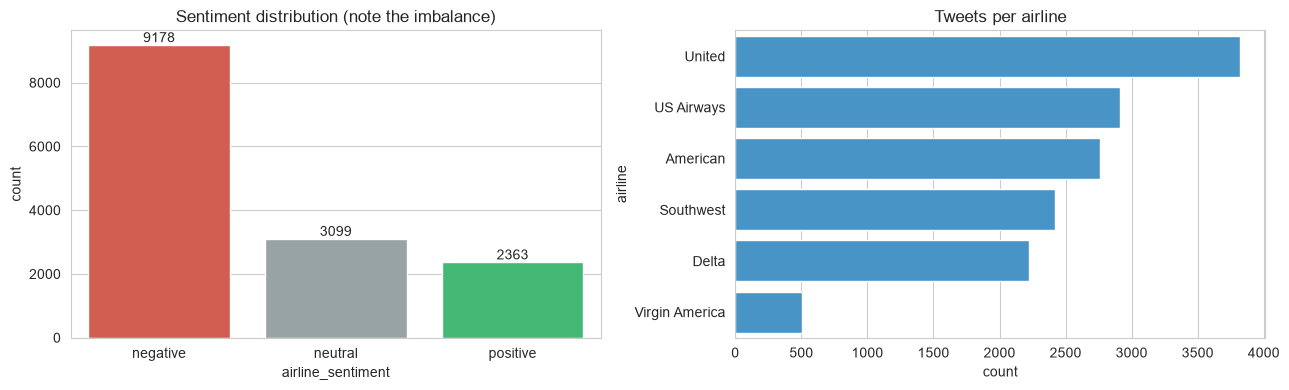

Class balance (%):
airline_sentiment
negative    62.7
neutral     21.2
positive    16.1
Name: proportion, dtype: float64


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

order = ['negative', 'neutral', 'positive']
sns.countplot(data=df, x='airline_sentiment', order=order,
              palette=['#e74c3c', '#95a5a6', '#2ecc71'], ax=ax[0])
ax[0].set_title('Sentiment distribution (note the imbalance)')
for c in ax[0].containers: ax[0].bar_label(c)

sns.countplot(data=df, y='airline',
              order=df['airline'].value_counts().index, ax=ax[1], color='#3498db')
ax[1].set_title('Tweets per airline')
plt.tight_layout(); plt.show()

dist = df['airline_sentiment'].value_counts(normalize=True).mul(100).round(1)
print('Class balance (%):'); print(dist)

> **Key insight — class imbalance.** 63% of tweets are *negative*, only 16% *positive*.
> A naive model that always predicts "negative" would score **63% accuracy** while being
> useless. This is precisely why we report **macro F1** as the headline metric (not accuracy)
> and train with **class weighting**. We'll see this play out in Phase 3.

### 1.3 Why tweets are messy — a before/after look

In [4]:
# Show what the raw text looks like vs our cleaning pipeline
sample = df.sample(5, random_state=42)[['airline_sentiment', 'text']].copy()
sample['cleaned'] = clean_series(sample['text'])
sample

,airline_sentiment,text,cleaned
4794,positive,@SouthwestAir you're my early frontrunner for best airline! #oscars2016,early frontrunner best airline oscar
10480,negative,@USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways a...,flt ewr cancel flightled yet flts nyc usairways still fly
8067,negative,@JetBlue what is going on with your BDL to DCA flights yesterday and today?! Why is every single...,go bdl dca flight yesterday today every single one get delay
8880,neutral,"@JetBlue do they have to depart from Washington, D.C.??",depart washington
8292,negative,@JetBlue I can probably find some of them. Are the ticket #s on there?,probably find ticket


### 1.4 Apply the cleaning pipeline to the whole dataset

In [5]:
df['clean_text'] = clean_series(df['text'])

# Drop rows that became empty after cleaning (pure mentions/URLs/numbers)
before = len(df)
df = df[df['clean_text'].str.strip().astype(bool)].copy()
print(f'Dropped {before - len(df)} empty-after-cleaning rows; {len(df)} remain.')

# Numeric label for modelling
df['label'] = df['airline_sentiment'].map(LABEL2ID)
df[['airline_sentiment', 'label', 'clean_text']].head()

Dropped 32 empty-after-cleaning rows; 14608 remain.


,airline_sentiment,label,clean_text
0,neutral,1,say
1,positive,2,plus add commercial experience tacky
2,neutral,1,not_today must mean need take another trip
3,negative,0,really aggressive blast obnoxious entertainment guest face little recourse
4,negative,0,really big bad thing


### 1.5 Word-frequency analysis — WordClouds per class

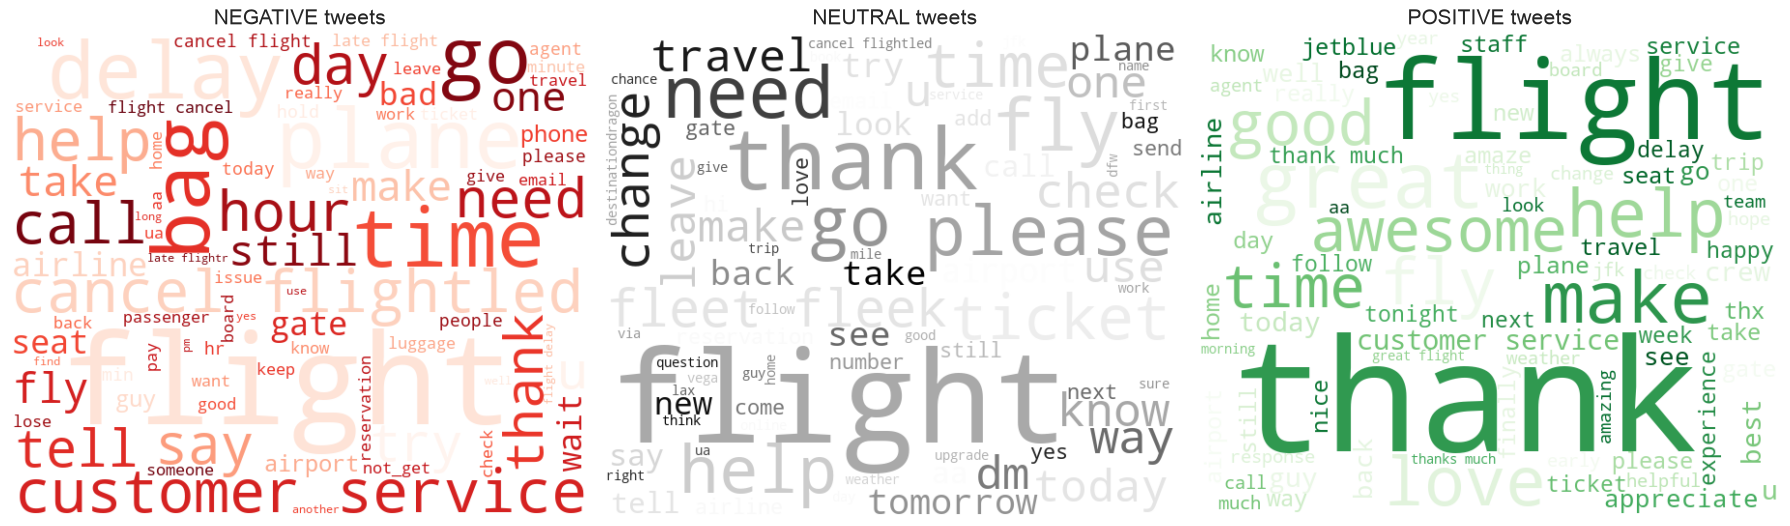

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {'negative': 'Reds', 'neutral': 'Greys', 'positive': 'Greens'}

for ax, sentiment in zip(axes, ['negative', 'neutral', 'positive']):
    text = ' '.join(df[df['airline_sentiment'] == sentiment]['clean_text'])
    wc = WordCloud(width=600, height=500, background_color='white',
                   colormap=colors[sentiment], max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.upper()} tweets', fontsize=15)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../reports/wordclouds.png', dpi=110, bbox_inches='tight')
plt.show()

> Notice the negation tokens like `not_*` surfacing in the negative cloud — proof our
> negation-handling upgrade is feeding real signal into the models. Positive clouds show
> *thank, great, awesome*; negative show *delay, hour, cancel, bag, not_*.

### 1.6 Save the cleaned dataset (hand-off to Phase 2)

In [7]:
df[['airline_sentiment', 'label', 'clean_text', 'text', 'tweet_created']] \
    .to_csv('../data/clean_tweets.csv', index=False)
print('Saved data/clean_tweets.csv ->', df.shape)

Saved data/clean_tweets.csv -> (14608, 17)


---
# Phase 2A — Classical NLP Baseline
*Goal: establish a fast, interpretable baseline.*

TF-IDF converts each tweet into a sparse numeric vector that highlights words that are
distinctive to that tweet. We then train two classic linear classifiers on top.

### 2.1 Train / test split (stratified to preserve class balance)

In [8]:
# .to_numpy(dtype=object) avoids pandas 2.x pyarrow-backed string arrays,
# which scikit-learn cannot index during a stratified split.
X = df['clean_text'].to_numpy(dtype=object)
y = df['label'].to_numpy(dtype=int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

Train: 11686  |  Test: 2922


### 2.2 TF-IDF vectorisation

In [9]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),   # unigrams + bigrams (captures 'cancel flight', 'not_good')
    min_df=2,             # ignore terms in <2 docs (noise)
    max_df=0.9,           # ignore terms in >90% of docs (too common)
    sublinear_tf=True,    # dampen high term counts
    max_features=20000)

Xtr = vectorizer.fit_transform(X_train)
Xte = vectorizer.transform(X_test)
print('TF-IDF matrix:', Xtr.shape, '(docs x features)')

TF-IDF matrix: (11686, 13580) (docs x features)


### 2.3 Model A — Logistic Regression (class-weighted for imbalance)

In [10]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
logreg.fit(Xtr, y_train)

pred_lr = logreg.predict(Xte)
print('Accuracy :', round(accuracy_score(y_test, pred_lr), 4))
print('Macro F1 :', round(f1_score(y_test, pred_lr, average='macro'), 4))
print()
print(classification_report(y_test, pred_lr, target_names=LABELS))

Accuracy : 0.7704
Macro F1 : 0.7233

              precision    recall  f1-score   support

    negative       0.88      0.82      0.85      1835
     neutral       0.55      0.67      0.61       615
    positive       0.71      0.72      0.72       472

    accuracy                           0.77      2922
   macro avg       0.71      0.74      0.72      2922
weighted avg       0.79      0.77      0.78      2922



### 2.4 Model B — Complement Naive Bayes (strong on imbalanced text)

In [11]:
nb = ComplementNB()
nb.fit(Xtr, y_train)

pred_nb = nb.predict(Xte)
print('Accuracy :', round(accuracy_score(y_test, pred_nb), 4))
print('Macro F1 :', round(f1_score(y_test, pred_nb, average='macro'), 4))
print()
print(classification_report(y_test, pred_nb, target_names=LABELS))

Accuracy : 0.7734
Macro F1 : 0.686

              precision    recall  f1-score   support

    negative       0.82      0.92      0.86      1835
     neutral       0.64      0.42      0.51       615
    positive       0.70      0.67      0.68       472

    accuracy                           0.77      2922
   macro avg       0.72      0.67      0.69      2922
weighted avg       0.76      0.77      0.76      2922



### 2.5 Confusion matrix — Logistic Regression

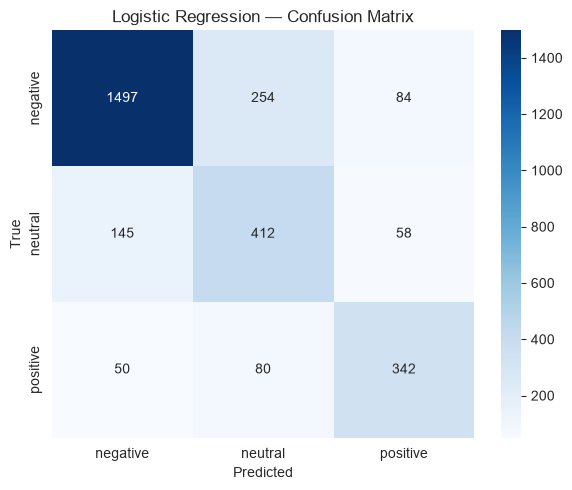

In [12]:
cm = confusion_matrix(y_test, pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS)
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/cm_logreg.png', dpi=110, bbox_inches='tight')
plt.show()

### 2.6 Explainability — what words drive each prediction? *(our upgrade)*
A marketing team will only trust a model it can interpret. Logistic Regression lets us read
the most influential words per class straight from the coefficients.

In [13]:
feature_names = np.array(vectorizer.get_feature_names_out())
for class_id, class_name in ID2LABEL.items():
    top = np.argsort(logreg.coef_[class_id])[-12:][::-1]
    print(f'{class_name.upper():>9}: ' + ', '.join(feature_names[top]))

 NEGATIVE: hour, delay, bad, bag, hr, hold, wait, pay, customer, lose, call, fail
  NEUTRAL: hi, dm, policy, need, possible, question, delay cancel, carry, ceo, currently, avgeek, destinationdragons


 POSITIVE: great, thanks, thank, love, awesome, best, thx, amaze, appreciate, kudos, excellent, helpful


### 2.7 Custom inference test (the brief's examples)

In [14]:
def predict_classical(text, model):
    vec = vectorizer.transform([clean_tweet(text)])
    probs = model.predict_proba(vec)[0]
    idx = int(np.argmax(probs))
    return ID2LABEL[idx], float(probs[idx])

tests = [
    "The service was amazing!",
    "I waited 4 hours just to get a cold burger.",
    "@united my flight is delayed again, not happy at all",
    "Thanks for the smooth check-in, great crew!",
    "What time does the gate open?",
]
for t in tests:
    label, conf = predict_classical(t, logreg)
    print(f'[{label:>8}  {conf:.0%}]  {t}')

[positive  94%]  The service was amazing!
[negative  92%]  I waited 4 hours just to get a cold burger.
[negative  95%]  @united my flight is delayed again, not happy at all
[positive  99%]  Thanks for the smooth check-in, great crew!
[ neutral  44%]  What time does the gate open?


### 2.8 Persist the classical artifacts

In [15]:
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
joblib.dump(logreg, '../models/logreg_model.pkl')
joblib.dump(nb, '../models/naivebayes_model.pkl')

# Save metrics for the Phase 3 comparison report
import json
classical_metrics = {
    'LogisticRegression': {
        'accuracy': round(accuracy_score(y_test, pred_lr), 4),
        'macro_f1': round(f1_score(y_test, pred_lr, average='macro'), 4),
        'weighted_f1': round(f1_score(y_test, pred_lr, average='weighted'), 4),
    },
    'ComplementNB': {
        'accuracy': round(accuracy_score(y_test, pred_nb), 4),
        'macro_f1': round(f1_score(y_test, pred_nb, average='macro'), 4),
        'weighted_f1': round(f1_score(y_test, pred_nb, average='weighted'), 4),
    },
}
with open('../reports/classical_metrics.json', 'w') as f:
    json.dump(classical_metrics, f, indent=2)
print('Saved models + metrics.'); print(json.dumps(classical_metrics, indent=2))

Saved models + metrics.
{
  "LogisticRegression": {
    "accuracy": 0.7704,
    "macro_f1": 0.7233,
    "weighted_f1": 0.7761
  },
  "ComplementNB": {
    "accuracy": 0.7734,
    "macro_f1": 0.686,
    "weighted_f1": 0.7603
  }
}


---
### Phase 1 + 2A complete ✅
- Cleaned dataset → `data/clean_tweets.csv`
- WordClouds → `reports/wordclouds.png`
- Models → `models/tfidf_vectorizer.pkl`, `logreg_model.pkl`, `naivebayes_model.pkl`
- Metrics → `reports/classical_metrics.json`

**Next:** `02_Deep_Learning_LSTM.ipynb` builds the contextual deep-learning model and we
compare the two approaches head-to-head in Phase 3.